## Setup and Theory 
I will choose $\sigma^2$ to be 2.0 and a length scale $l =  2.0$ and generate data points $X$ of size $n \times p$ where $n=100$ and $p=10$ from a multivariate normal $$\mathcal{N}(0, I_p)$$.
Then I will compute the kernel matrix $K$ using the RBF kernel formula, for all pairs of data points in $X$. 
so $K$ will look like:
$$K^{true}_{ij} = \sigma^2 \exp\left(-\frac{||X_i - X_j||^2}{2l^2}\right)$$
where $X_i$ and $X_j$ are the $i^{th}$ and $j^{th}$ rows of $X$ respectively.

After that, I will use our network with: 
$$K_{(i,j)}^{(k)} = K^{(k)}(f^{(k)}(x_i^{(k)}), f^{(k)}(x_j^{(k)}))$$

And then to get the entry $$K_{(i,j)}= \sum_{k=1}^{p} \alpha_k K_{(i,j)}^{(k)}$$

The learnable parameters will be $ K^{(k)}$. Later on we will navigate to learning the functional form of each $f^{(k)}$ as well. Alongide lookuing at learning $\alpha_k$ as well. Maybe even add a lasso regularization on $\alpha_k$ to promote sparsity, and so we might be able to start using this for feature selection as well. And so for now we will fix $\alpha_k = 1$ for all $k=1,...,p$. And fix $f^{(k)}$ to be the identity function for now (i.e. $f^{(k)}(x) = x$).

<!-- Now what I mean by $f^{(k)}$ is a learnable transformation from the k'th feature to some other space (i.e. $f^{(k)}: \mathbb{R} \rightarrow \mathbb{R}^{d_k}$ where $d_k=1$ for now). We will also fix this to be a non-linear of a linear transformation for this experiment (i.e. $f^{(k)}(x) = \tau (w_k x + b_k)$ where $w_k, b_k$ are learnable parameters), and $\tau$ is a non-linear activation function (ReLU, Tanh, Sigmoid, etc). (For this experiment I will choose $\tau=RelU$) -->

Now what I mean by $K^{(k)}$ is learning the parameters of the kernel function (which in this case is the RBF kernel). So for the RBF kernel we have:
$$K^{(k)}(X_i,X_j) = \sigma_k^2 \exp\left(-\frac{||X_i^{(k)} - X_j^{(k)}||^2}{2l_k^2}\right)$$
where $\sigma_k^2$, $l_k^2$ are learnable parameters.

So in short the learnable parameters are:
- $\sigma_k^2$ for $k=1,...,p$ which I am gonna initialize using a $\mathcal{N}(1.0, 0.1)$
- $l_k$ for $k=1,...,p$ which I am gonna initialize using a $\mathcal{N}(1.0, 0.1)$

**IMPORTANT NOTE** about adding noise to the kernel matrix:
In this case I added two types of noise: 
* Adding noise to the diagonal only (i.e. $K^{true}_{observed} = K^{true} + diag(e)$ where $e \sim \mathcal{N}(0, \sigma_{noise}^2 I_n)$)
* Adding noise to every entry (i.e. $K^{true}_{observed} = K^{true} + N$ where $N_{ij} \sim \mathcal{N}(0, \sigma_{noise}^2)$ i.i.d)
* Of course adding on the diagnoal only will perform better. Also note that perturbing X directly won't have any effect on the learning since we are trying to learn the mapping of the kernel matrix and not the data points themselves (so in simple terms I do not care where X is coming from, I only care about the kernel matrix that is computed from X). So adding noise to X will only change the kernel matrix but won't add any useful information for the learning process. 
* Maybe what would be interesting here is to add noise to X but keep the kernel matrix fixed (i.e. not changing it according to the perturbed X) and see how that affects the learning process. But I will leave that for future work.


Now for the objective function we will minimize the Frobenius norm between the true kernel matrix and the learned kernel matrix:
$$L = ||K^{true}_{observed} - K||_F^2$$
**BUT** since the Frobenius norm results in very large values and makes the training unstable, I will minimize the mean squared error between the two matrices instead:
$$L = \frac{1}{n^2} \sum_{i=1}^{n} \sum_{j=1}^{n} (K^{true}_{observed,ij} - K_{ij})^2$$
**NOTE**: we do not care to compute the loss on all entries of ther kernel matrix, since by construction the kernel matrix is symmetric and positive definite. So we can compute the loss on the upper triangular part of the matrix only (including the diagonal). But for simplicity I will compute the loss on all entries for now.

## results anlysis


## How to run: 
* You can simply import the libraieis and run the cell that is Fast Training Loop the rest are just cells for illustration and understanding. 

In [2]:
import torch
import matplotlib.pyplot as plt

#### Fast Training Loop (Efficient but harder to look at) (#NOTE this is for multiple noise levels)

In [ ]:
torch.manual_seed(0)
array_of_noise_sigma_square = [0.0001, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]  #  0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5
train_error_last_epoch_for_each_experiment_mse = []
train_error_last_epoch_for_each_experiment_fb = []
# plot this against the last train error 
for noise_sigma_square in array_of_noise_sigma_square:
    # nature 
    n = 200
    p = 10
    X = torch.distributions.multivariate_normal.MultivariateNormal(
        loc=torch.ones(p),
        covariance_matrix=  10 * torch.eye(p)
    ).sample((n,))  # (n, p)
    true_sigma_square = 2.0
    true_square_length_scale = 2.0
    # K_TRUE is a n x n kernel matrix with linear kernel plus noise

    K_TRUE = true_sigma_square * torch.exp(-torch.cdist(X, X, p=2)**2 / (2 * true_square_length_scale))  # RBF kernel
    # """Adding noise on the dianoal only"""
    # noise = torch.distributions.Normal(0, noise_sigma_square).sample((n,))
    
    # K_TRUE_observed = K_TRUE + torch.diag(noise) # here assuming noise is added to the diagonal

    # """Adding noise on every entry (I.I.D)"""
    noise_matrix = torch.distributions.Normal(0, noise_sigma_square).sample((n,n))
    K_TRUE_observed = K_TRUE + noise_matrix
    
    
    # researcher 
    
    sigmas_pred = torch.distributions.normal.Normal(1.0, 0.1).sample((p,1)).requires_grad_(True)
    length_scales_pred = torch.distributions.normal.Normal(1.0, 0.1).sample((p,1)).requires_grad_(True)

    learning_rate = 0.01
    epochs = 1000
    losses_mse = []
    losses_fb = []
    for epoch in range(epochs):

        # ----- Compute feature-wise squared distances -----
        diff = X.unsqueeze(1) - X.unsqueeze(0)        # (n, n, p)
        sq_diff = diff * diff                         # (n, nreplication_of_kernels/linear_kernel/linear_kernel.ipynbreplication_of_kernels/linear_kernel/linear_kernel.ipynb p)

        # ----- Parameters -----
        sigma2 = (sigmas_pred.squeeze()) ** 2         # (p,)
        l2 = (length_scales_pred.squeeze()) ** 2      # (p,)

        # ----- RBF per feature -----
        # sq_diff: (n,n,p)
        # l2:      (p,)      → broadcast
        # sigma2:  (p,)      → broadcast
        rbf_per_feature = torch.exp(-sq_diff / (2*l2)) * sigma2   # (n,n,p)

        K_pred = rbf_per_feature.sum(dim=2)           # (n,n)

        # ----- Loss -----
        diffK = K_TRUE_observed - K_pred
        loss = (diffK * diffK).mean()

        fro_loss = torch.norm(diffK, p='fro')**2      # log only

        losses_mse.append(loss.item())
        losses_fb.append(fro_loss.item())

        # ----- Backprop -----
        loss.backward()

        # ----- SGD update -----
        with torch.no_grad():
            sigmas_pred -= learning_rate * sigmas_pred.grad
            length_scales_pred -= learning_rate * length_scales_pred.grad

            sigmas_pred.grad.zero_()
            length_scales_pred.grad.zero_()

        if epoch % 10 == 0:
            pass
            # print(f"Epoch {epoch}, MSE Loss: {loss.item()}, Frobenius Loss: {fro_loss.item()}"
        # ---- Frobenius loss and MSE ---
    print(f"Noise level: {noise_sigma_square}, Final MSE Loss: {losses_mse[-1]}, Final Frobenius Loss: {losses_fb[-1]}")
    print(f"Learned sigmas^2: {(sigmas_pred**2 )}")
    print(f"Learned length scales^2: {(length_scales_pred**2)}")
    train_error_last_epoch_for_each_experiment_mse.append(losses_mse[-1])
    train_error_last_epoch_for_each_experiment_fb.append(losses_fb[-1])

Noise level: 0.0001, Final MSE Loss: 0.018850799649953842, Final Frobenius Loss: 754.0316772460938
Learned sigmas^2: tensor([[0.0156],
        [0.0444],
        [0.0453],
        [0.0736],
        [0.0297],
        [0.0386],
        [0.0254],
        [0.0493],
        [0.0365],
        [0.0350]], grad_fn=<PowBackward0>)
Learned length scales^2: tensor([[1.1710],
        [0.5143],
        [0.5556],
        [0.3304],
        [0.8212],
        [0.6309],
        [0.9887],
        [0.4926],
        [0.6872],
        [0.8767]], grad_fn=<PowBackward0>)
Noise level: 0.1, Final MSE Loss: 0.018817566335201263, Final Frobenius Loss: 752.7025146484375
Learned sigmas^2: tensor([[0.0391],
        [0.0389],
        [0.0365],
        [0.0551],
        [0.0527],
        [0.0418],
        [0.0241],
        [0.0593],
        [0.0235],
        [0.0314]], grad_fn=<PowBackward0>)
Learned length scales^2: tensor([[0.6228],
        [0.5449],
        [0.5392],
        [0.4264],
        [0.4117],
        [0.542

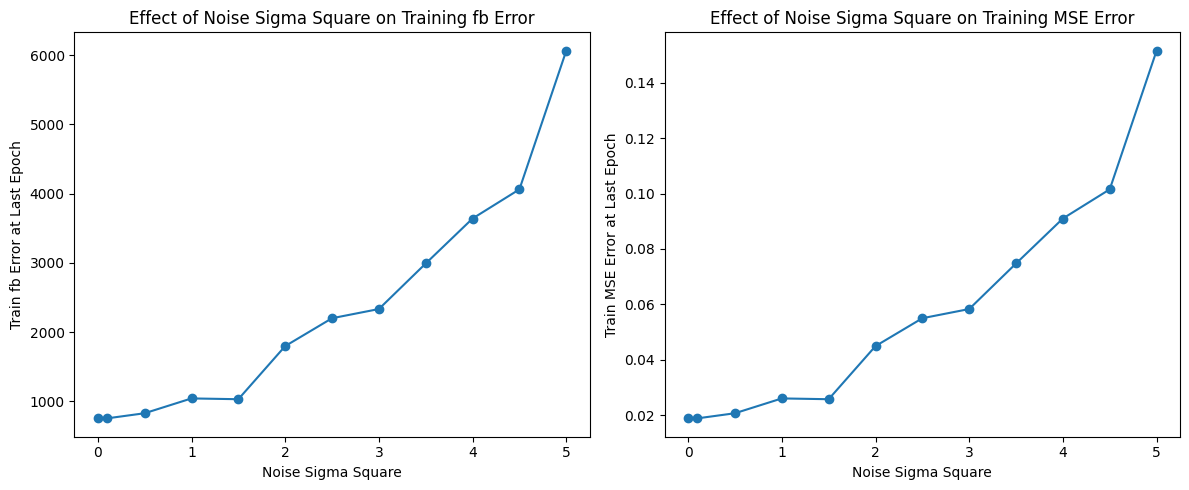

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: fb error ---
axes[0].plot(array_of_noise_sigma_square,
             train_error_last_epoch_for_each_experiment_fb,
             marker='o')
axes[0].set_xlabel('Noise Sigma Square')
axes[0].set_ylabel('Train fb Error at Last Epoch')
axes[0].set_title('Effect of Noise Sigma Square on Training fb Error')

# --- Right plot: MSE error ---
axes[1].plot(array_of_noise_sigma_square,
             train_error_last_epoch_for_each_experiment_mse,
             marker='o')
axes[1].set_xlabel('Noise Sigma Square')
axes[1].set_ylabel('Train MSE Error at Last Epoch')
axes[1].set_title('Effect of Noise Sigma Square on Training MSE Error')
plt.savefig('noise_vs_train_error_rbf_kernel.png')
plt.tight_layout()
plt.show()

